# Classifying Penguins with Keras Day 2

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [2]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# drop Nan rows
penguins.dropna(inplace=True)

In [4]:
# defining X
penguins_x = pd.concat([
    penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']],
    pd.get_dummies(penguins['sex'])
], axis=1)
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42
)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1,
       2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1,
       1, 2, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2,
       0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 1, 1, 0, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 0,
       0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0, 2, 0], dtype=int8)

In [5]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 , -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,  0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,  0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,  0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,  0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 , -1.0461779 ]], shape=(266, 6))

### Defining the model

In [6]:
tf.random.set_seed(42)

In [7]:
# construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [8]:
model.summary()

Model: "penguin_model"
┌──────────────────────────────────────┬─────────────────────────────┬─────────────────┐
│ Layer (type)                         │ Output Shape                │         Param # │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ input_layer (InputLayer)             │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │              49 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────

### Model training parameters (compile) & model training (fit)

In [9]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

scores = model.evaluate(X_test_scaled, y_test, verbose=1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.3726 - loss: 1.2541 - val_accuracy: 0.3333 - val_loss: 1.2698
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3915 - loss: 1.2458 - val_accuracy: 0.3333 - val_loss: 1.2606
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4009 - loss: 1.2379 - val_accuracy: 0.3333 - val_loss: 1.2517
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4009 - loss: 1.2302 - val_accuracy: 0.3333 - val_loss: 1.2429
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4057 - loss: 1.2227 - val_accuracy: 0.3333 - val_loss: 1.2342
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4198 - loss: 1.2154 - val_accuracy: 0.3333 - val_loss: 1.2257
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4198 - loss: 1.2082 - val_accuracy: 0.3333 - val_loss: 1.2174
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4198 - loss: 1.2010 - val_accuracy: 0.3704 - val_loss: 1.2094

### Evaluating on the test data

In [10]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\nTest Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Test Set Evaluation:
Test Accuracy: 0.4328
Test Precision: 0.2368
Test Recall: 0.4328
Test F1 Score: 0.3062
Test ROC AUC Score: 0.3305


C:\Users\karis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Evaluating model training using loss and accuracy

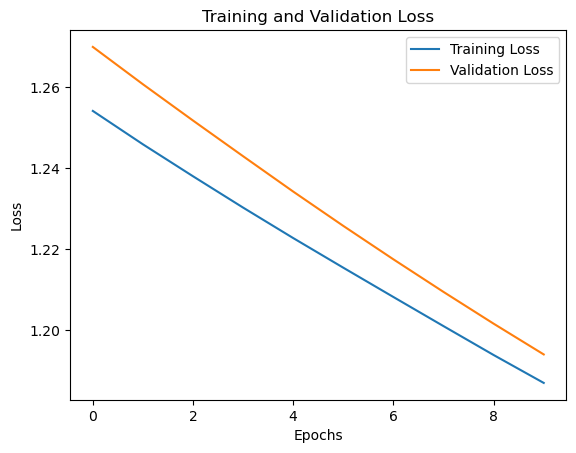

In [11]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

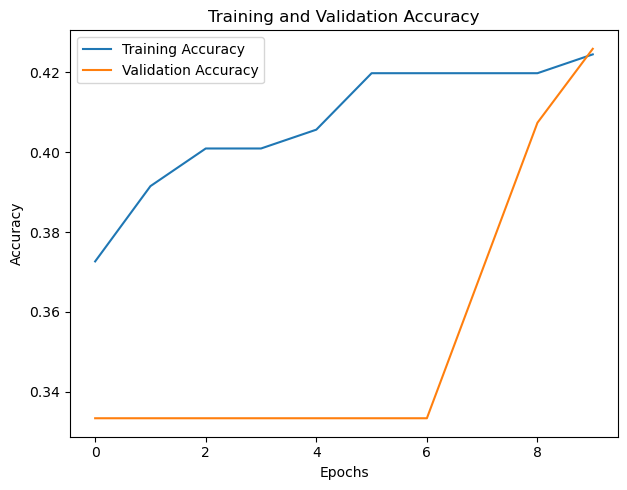

In [12]:
# plot the training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

Running the model three times without a random seed produced very different results each time. Validation accuracy ranged from roughly 0.4 to 0.9 across the three runs, and the training and validation curves took different shapes. The curves are different because the neural network sets weights randomly at the start of each run and different starting weights lead to different optimization paths. So, overall the model ends up in different solutions even when trained on the same data. We don't set a random seed yet, plus the data itself is smaller so any changes might be a little more visible.

Run 1  Val Accuracy 0.7222  Val Loss 0.9502
Run 2  Val Accuracy 0.5556  Val Loss 0.9002
Run 3  Val Accuracy 0.5926  Val Loss 0.9833


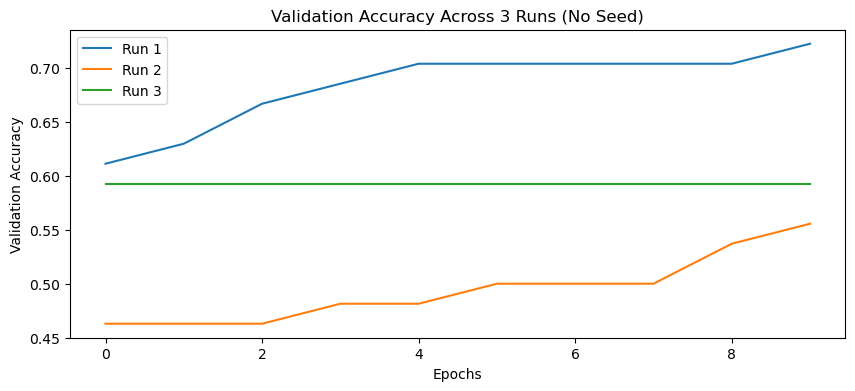

In [ ]:
# Run the model 3 times without a seed to observe variability
#creating plot and output summaries to see changes more easily
#in class also just ran the above code 3 separate times, but scrolling got annoying so I summarized it all within this code
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

for run in range(1, 4):
    inputs_v = keras.Input(shape=(6,))
    x_v = layers.Dense(7, activation='relu')(inputs_v)
    x_v = layers.Dense(5, activation='relu')(x_v)
    outputs_v = layers.Dense(3, activation='softmax')(x_v)
    model_v = keras.Model(inputs=inputs_v, outputs=outputs_v)

    model_v.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy'],
    )

    history_v = model_v.fit(
        X_train_scaled, y_train,
        batch_size=128, epochs=10,
        validation_split=0.2, verbose=0
    )

    val_acc = history_v.history['val_accuracy'][-1]
    val_loss_v = history_v.history['val_loss'][-1]
    print(f"Run {run}  Val Accuracy {val_acc:.4f}  Val Loss {val_loss_v:.4f}")
    plt.plot(history_v.history['val_accuracy'], label=f'Run {run}')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Across 3 Runs (No Seed)')
plt.legend()
plt.show()

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

A random seed was added before constructing the model (done in class). It affects training by making the model start from the same point each run and therefore follow the same optimization path. This reduces some variability in the training and validation curves over many different runs, basically will see less of a difference in accuracy scores and curves. However, with only 10 epochs the model is still underfitting, so some variability remains even after setting a seed. A random seed will not completely eliminate variability but it makes results more reproducible and easier to compare across configurations (will need to combine approaches and discussed in class).

`tf.random.set_seed(42)` is placed before model call

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

Config 1: (1) Two flat layers of 16 neurons each. (2) Test accuracy 1.0000, test loss 0.0955. (3) Both curves rose smoothly together and leveled off around epoch 20 with no overfitting.

Config 2: (1) A deeper funnel with layers of 32, 16, and 8 neurons. (2) Test accuracy 1.0000, test loss 0.0272. (3) Validation jumped ahead of training early and was noisier in the middle before both converged around epoch 35.

Config 3: (1) A single hidden layer of 32 neurons. (2) Test accuracy 0.9851, test loss 0.1935. (3) Both curves climbed slowly and were still improving at epoch 50, suggesting one layer was not enough capacity for this task.

Configs 1 and 2 both hit perfect test accuracy. Config 1 converged the fastest and most cleanly, making it the best overall for this dataset.

Config 1 [16, 16]  Test Loss 0.0955  Test Accuracy 1.0000


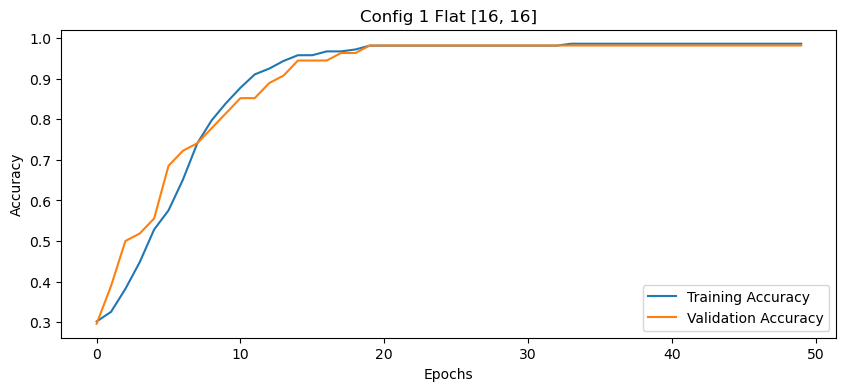

In [ ]:
# Configuration 1: Flat layout with two layers of 16 neurons each

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Set random seed for reproducible results
tf.random.set_seed(42)

# Define input layer with 6 features
inputs = keras.Input(shape=(6,))

# Add first hidden layer with 16 neurons and ReLU activation
x = layers.Dense(16, activation='relu')(inputs)

# Add second hidden layer with 16 neurons and ReLU activation
x = layers.Dense(16, activation='relu')(x)

# Add output layer with 3 neurons and softmax activation
outputs = layers.Dense(3, activation='softmax')(x)

# Create the model
model_c1 = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model with loss function, optimizer, and accuracy metric
model_c1.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train the model for 50 epochs
h1 = model_c1.fit(X_train_scaled, y_train, batch_size=64, epochs=50,
                  validation_split=0.2, verbose=0)

# Evaluate the model on test data
s1 = model_c1.evaluate(X_test_scaled, y_test, verbose=0)

# Print test loss and accuracy
print(f"Config 1 [16, 16]  Test Loss {s1[0]:.4f}  Test Accuracy {s1[1]:.4f}")

# Create a new figure for plotting
plt.figure(figsize=(10, 4))

# Plot training accuracy
plt.plot(h1.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(h1.history['val_accuracy'], label='Validation Accuracy')

# Label x-axis
plt.xlabel('Epochs')

# Label y-axis
plt.ylabel('Accuracy')

# Add plot title
plt.title('Config 1 Flat [16, 16]')

# Show legend on plot
plt.legend()

# Display the plot
plt.show()

Config 2 [32, 16, 8]  Test Loss 0.0272  Test Accuracy 1.0000


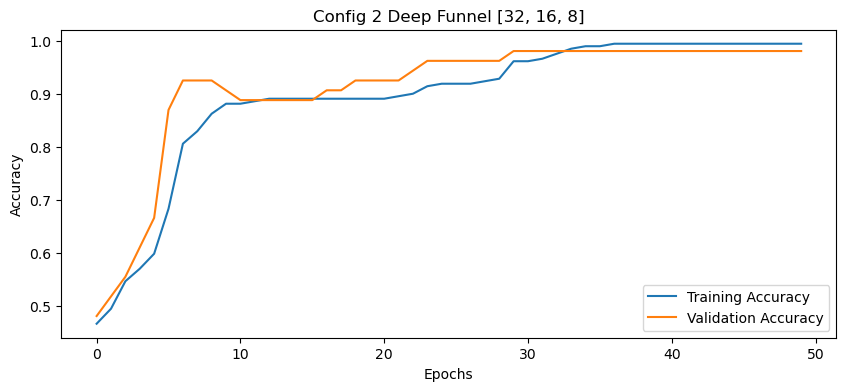

In [ ]:
# Configuration 2: Deeper funnel with layers of 32, 16, and 8 neurons

# Set random seed for reproducible results
tf.random.set_seed(42)

# Define input layer with 6 features
inputs = keras.Input(shape=(6,))

# Add first hidden layer with 32 neurons and ReLU activation
x = layers.Dense(32, activation='relu')(inputs)

# Add second hidden layer with 16 neurons and ReLU activation
x = layers.Dense(16, activation='relu')(x)

# Add third hidden layer with 8 neurons and ReLU activation
x = layers.Dense(8, activation='relu')(x)

# Add output layer with 3 neurons and softmax activation
outputs = layers.Dense(3, activation='softmax')(x)

# Create the model
model_c2 = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model with loss function, optimizer, and accuracy metric
model_c2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train the model for 50 epochs
h2 = model_c2.fit(X_train_scaled, y_train, batch_size=64, epochs=50,
                  validation_split=0.2, verbose=0)

# Evaluate the model on test data
s2 = model_c2.evaluate(X_test_scaled, y_test, verbose=0)

# Print test loss and accuracy
print(f"Config 2 [32, 16, 8]  Test Loss {s2[0]:.4f}  Test Accuracy {s2[1]:.4f}")

# Create a new figure for plotting
plt.figure(figsize=(10, 4))

# Plot training accuracy
plt.plot(h2.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(h2.history['val_accuracy'], label='Validation Accuracy')

# Label x-axis
plt.xlabel('Epochs')

# Label y-axis
plt.ylabel('Accuracy')

# Add plot title
plt.title('Config 2 Deep Funnel [32, 16, 8]')

# Show legend on plot
plt.legend()

# Display the plot
plt.show()

Config 3 [32]  Test Loss 0.1935  Test Accuracy 0.9851


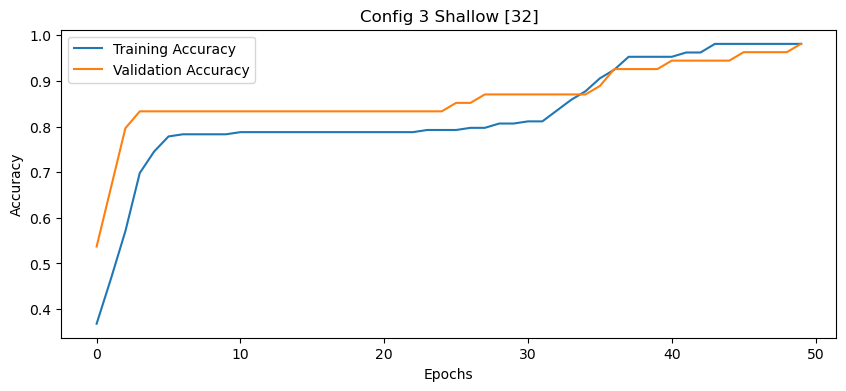

In [ ]:
# Configuration 3: Shallow layout with a single hidden layer of 32 neurons

# Set random seed for reproducible results
tf.random.set_seed(42)

# Define input layer with 6 features
inputs = keras.Input(shape=(6,))

# Add hidden layer with 32 neurons and ReLU activation
x = layers.Dense(32, activation='relu')(inputs)

# Add output layer with 3 neurons and softmax activation
outputs = layers.Dense(3, activation='softmax')(x)

# Create the model
model_c3 = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model with loss function, optimizer, and accuracy metric
model_c3.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train the model for 50 epochs
h3 = model_c3.fit(X_train_scaled, y_train, batch_size=64, epochs=50,
                  validation_split=0.2, verbose=0)

# Evaluate the model on test data
s3 = model_c3.evaluate(X_test_scaled, y_test, verbose=0)

# Print test loss and accuracy
print(f"Config 3 [32]  Test Loss {s3[0]:.4f}  Test Accuracy {s3[1]:.4f}")

# Create a new figure for plotting
plt.figure(figsize=(10, 4))

# Plot training accuracy
plt.plot(h3.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(h3.history['val_accuracy'], label='Validation Accuracy')

# Label x-axis
plt.xlabel('Epochs')

# Label y-axis
plt.ylabel('Accuracy')

# Add plot title
plt.title('Config 3 Shallow [32]')

# Show legend on plot
plt.legend()

# Display the plot
plt.show()

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

**10 epochs:** (1) 10 epochs. (2) Test accuracy 0.7761, test loss 0.8467. (3) The curve rose quickly in the first few epochs then stopped around 0.75 validation accuracy, well before converging (The model needs training more).

**50 epochs:** (1) 50 epochs. (2) Test accuracy 0.9851, test loss 0.1283. (3) The curve kept climbing gradually through all 50 epochs and had not fully plateaued by the end (originally I thought it potentially needs more training, but now I see that it flattens out after 50 mostly). 

**100 epochs:** (1) 100 epochs. (2) Test accuracy 1.0000, test loss 0.0374. (3) The curve continued rising until around epoch 40 to 45 and then flattened out, indicating the model had fully converged.

The minimum number of epochs needed for reliable performance was around 50, but 100 does give the best result (might not be worth it in a real job setting)

Epochs 10  Test Loss 0.8467  Test Accuracy 0.7761
Epochs 50  Test Loss 0.1283  Test Accuracy 0.9851
Epochs 100  Test Loss 0.0374  Test Accuracy 1.0000


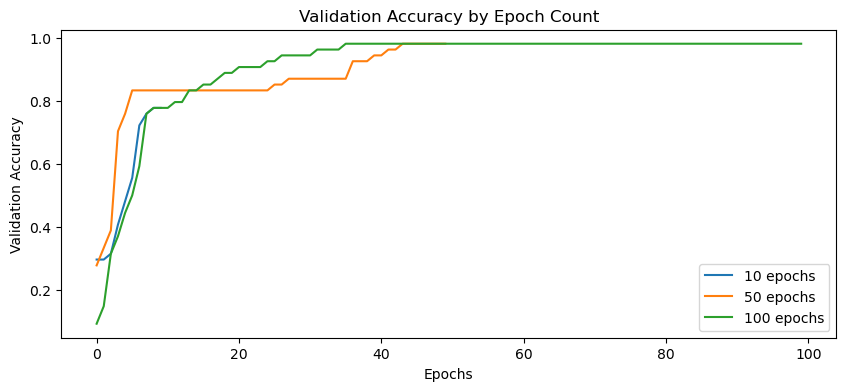

In [17]:
# Vary the number of epochs and observe the effect on performance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

for n_epochs in [10, 50, 100]:
    tf.random.set_seed(42)
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(16, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    model_e = keras.Model(inputs=inputs, outputs=outputs)
    model_e.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    h_e = model_e.fit(X_train_scaled, y_train, batch_size=64, epochs=n_epochs,
                      validation_split=0.2, verbose=0)
    s_e = model_e.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Epochs {n_epochs}  Test Loss {s_e[0]:.4f}  Test Accuracy {s_e[1]:.4f}")
    plt.plot(h_e.history['val_accuracy'], label=f'{n_epochs} epochs')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy by Epoch Count')
plt.legend()
plt.show()

### Early stopping, l2 regularization and dropout

Doing all these for penguins is probably overkill!

In [18]:
# sample model

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output -> probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

# this is setting the early stop!
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 20% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3585 - loss: 1.2449 - val_accuracy: 0.4444 - val_loss: 1.2335
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4009 - loss: 1.2481 - val_accuracy: 0.4444 - val_loss: 1.2311
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4104 - loss: 1.2345 - val_accuracy: 0.4444 - val_loss: 1.2287
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3915 - loss: 1.2360 - val_accuracy: 0.4444 - val_loss: 1.2262
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3868 - loss: 1.2271 - val_accuracy: 0.4444 - val_loss: 1.2238
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4245 - loss: 1.2301 - val_accuracy: 0.4444 - val_loss: 1.2214
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4057 - loss: 1.2243 - val_accuracy: 0.4444 - val_loss: 1.2191
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4198 - loss: 1.2293 - val_accuracy: 0.4444 - val_loss:

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

Based on the experiments above, validation_split is set to 0.2, epochs is set to 100, and verbose is set to 0. These settings produced reliable and stable results on this dataset.

In [22]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes -> softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=100,  # 100 epochs found to be best from epoch experiments above
        validation_split=0.2,  # 0.2 kept consistent with all prior experiments
        verbose=0,  # suppress output during tuning so trial results stay readable
        callbacks=[early_stop]  # early stopping prevents wasted epochs if model converges early
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-15 22:38:30,958] A new study created in memory with name: no-name-9a9d7658-7065-49f4-a9d5-72e56e6c7943
[I 2026-05-15 22:38:34,446] Trial 0 finished with value: 0.032715849578380585 and parameters: {'num_layers': 2, 'learning_rate': 0.0053330162779225455, 'batch_size': 32, 'num_units_layer_1': 32, 'num_units_layer_2': 18}. Best is trial 0 with value: 0.032715849578380585.
[I 2026-05-15 22:38:46,674] Trial 1 finished with value: 0.028899969533085823 and parameters: {'num_layers': 2, 'learning_rate': 0.0010130195018120316, 'batch_size': 16, 'num_units_layer_1': 9, 'num_units_layer_2': 19}. Best is trial 1 with value: 0.028899969533085823.
[I 2026-05-15 22:38:51,114] Trial 2 finished with value: 0.03319142386317253 and parameters: {'num_layers': 1, 'learning_rate': 0.006258985465422374, 'batch_size': 16, 'num_units_layer_1': 28}. Best is trial 1 with value: 0.028899969533085823.
[I 2026-05-15 22:39:02,839] Trial 3 finished with value: 0.04549603909254074 and parameters: {'num_la

Best validation loss: 0.010624043643474579
Best parameters: {'num_layers': 3, 'learning_rate': 0.008296657844031725, 'batch_size': 32, 'num_units_layer_1': 17, 'num_units_layer_2': 22, 'num_units_layer_3': 30}


In [23]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [24]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)

best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)

history = best_model.fit(
    X_train_scaled, y_train,
    batch_size=batch_size,
    epochs=100,
    validation_split=0.2,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
)

scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\nBest Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6557 - loss: 0.8663 - val_accuracy: 0.8519 - val_loss: 0.5264
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8302 - loss: 0.3810 - val_accuracy: 0.9815 - val_loss: 0.2075
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9764 - loss: 0.1296 - val_accuracy: 0.9630 - val_loss: 0.0904
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0331 - val_accuracy: 0.9815 - val_loss: 0.0418
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0110 - val_accuracy: 0.9815 - val_loss: 0.0371
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9815 - val_loss: 0.0407
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9815 - val_loss: 0.0455
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9815 - val_loss: 0.05